# BanglaCXR — Local Anaconda Version

## Cell 1: Package Setup

In [15]:
import sys
print(f'Python: {sys.version}')
!{sys.executable} -m pip install -q transformers==5.9.0 peft==0.19.1 accelerate==1.13.0 bitsandbytes==0.49.2 trl datasets timm einops scikit-learn nltk rouge-score sacrebleu Pillow pandas matplotlib seaborn
print('Done. RESTART KERNEL NOW, then start from Cell 2.')

Python: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
Done. RESTART KERNEL NOW, then start from Cell 2.


## Cell 2 — Local Paths

In [1]:
import os

IU_XRAY_BASE = r'C:\Users\faisal\Downloads\Ahasan\Thesis\data\iu_xray'

WORKING_DIR = './BanglaCXR_Local'
LOG_DIR = os.path.join(WORKING_DIR, 'logs')
MODEL_DIR = os.path.join(WORKING_DIR, 'models')
for d in [LOG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

REPORTS_CSV = os.path.join(IU_XRAY_BASE, 'indiana_reports.csv')
PROJECTIONS_CSV = os.path.join(IU_XRAY_BASE, 'indiana_projections.csv')

IMAGES_DIR = None
for root, dirs, _ in os.walk(IU_XRAY_BASE):
    if 'images_normalized' in dirs:
        IMAGES_DIR = os.path.join(root, 'images_normalized')
        break

assert os.path.exists(REPORTS_CSV), f"❌ Reports not found: {REPORTS_CSV}"
assert IMAGES_DIR is not None, "❌ images_normalized not found."

img_count = len([f for f in os.listdir(IMAGES_DIR) if f.endswith('.png')])
print(f'Paths verified. Images: {img_count}')

Paths verified. Images: 7470


## Cell 3: GPU Check

In [17]:
import torch
print(f'PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA GeForce RTX 5050 Laptop GPU | VRAM: 8.5 GB


## Cell 4: Imports & Seeds

In [2]:
import os, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, AutoModel, AutoImageProcessor,
    BitsAndBytesConfig, get_cosine_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Imports done.')

Imports done.


## Cell 5: Load & Clean Reports

In [3]:
reports = pd.read_csv(REPORTS_CSV)
projections = pd.read_csv(PROJECTIONS_CSV)

reports = reports.dropna(subset=['findings','impression'], how='all')
reports['findings'] = reports['findings'].fillna('')
reports['impression'] = reports['impression'].fillna('')
reports['report'] = 'Findings: ' + reports['findings'] + '\nImpression: ' + reports['impression']
reports = reports[reports['report'].str.len() > 30].reset_index(drop=True)
print(f'After cleaning: {len(reports)} reports')

After cleaning: 3826 reports


## Cell 6: Filter Frontal Views & Merge

In [4]:
frontal = projections[projections['projection'].str.contains('frontal', case=False, na=False)]
frontal = frontal.drop_duplicates(subset='uid').reset_index(drop=True)

df = pd.merge(frontal[['uid', 'filename']], reports[['uid', 'report']], on='uid')
df = df.drop_duplicates(subset='uid').reset_index(drop=True)

before = len(df)
df = df[df['filename'].apply(lambda f: os.path.exists(os.path.join(IMAGES_DIR, f)))].reset_index(drop=True)
print(f'After merge & image check: {len(df)} / {before}')

After merge & image check: 3666 / 3666


## Cell 7: Train/Val/Test Split

In [5]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 2566 | Val: 550 | Test: 550


## Cell 8: Visualize Samples

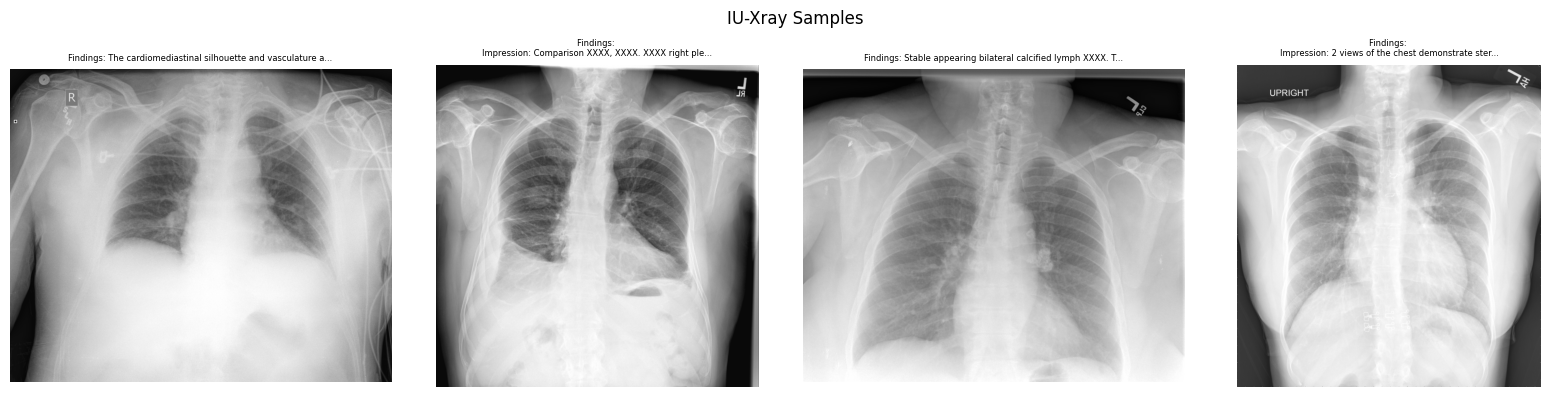

Saved.


In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    row = train_df.iloc[i]
    img = Image.open(os.path.join(IMAGES_DIR, row['filename'])).convert('L').convert('RGB')
    ax.imshow(img)
    ax.set_title(row['report'][:60]+'...', fontsize=6)
    ax.axis('off')
plt.suptitle('IU-Xray Samples', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'samples.png'), dpi=100)
plt.show()
print('Saved.')

## Cell 9: Load RAD-DINO (Frozen)

In [6]:
RAD_DINO_ID = 'microsoft/rad-dino'
image_processor = AutoImageProcessor.from_pretrained(RAD_DINO_ID)
rad_dino = AutoModel.from_pretrained(RAD_DINO_ID, torch_dtype=torch.float16).to(DEVICE)

for p in rad_dino.parameters(): p.requires_grad = False
rad_dino.eval()

with torch.no_grad():
    dummy = torch.zeros(1, 3, 518, 518, device=DEVICE, dtype=torch.float16)
    out = rad_dino(dummy)

VISUAL_DIM = out.last_hidden_state.shape[-1]
NUM_PATCHES = out.last_hidden_state.shape[1]
del dummy, out
torch.cuda.empty_cache()
print(f'RAD-DINO loaded. Dim: {VISUAL_DIM} | Patches: {NUM_PATCHES}')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

RAD-DINO loaded. Dim: 768 | Patches: 1370


## Cell 10: Anatomy-Guided Projector

In [7]:
class AnatomyGuidedProjector(nn.Module):
    def __init__(self, visual_dim=768, llm_dim=3072, num_regions=32, num_heads=8):
        super().__init__()
        self.num_regions = num_regions
        self.queries = nn.Parameter(torch.randn(num_regions, visual_dim))
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=visual_dim, 
            num_heads=num_heads, 
            batch_first=True,
            dropout=0.1
        )
        self.proj = nn.Sequential(
            nn.Linear(visual_dim, llm_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(llm_dim, llm_dim)
        )
        self.ln = nn.LayerNorm(llm_dim)

    def forward(self, visual_feats):
        if visual_feats.dtype != self.queries.dtype:
            visual_feats = visual_feats.to(self.queries.dtype)
        
        q = self.queries.unsqueeze(0).expand(visual_feats.size(0), -1, -1)
        attn_out, _ = self.cross_attn(q, visual_feats, visual_feats)
        out = self.proj(attn_out)
        return self.ln(out)

## Cell 11: Load Phi-3.5 Mini + QLoRA

In [8]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

llm = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3.5-mini-instruct",
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    attn_implementation="eager"
)

llm.gradient_checkpointing_enable()
llm = prepare_model_for_kbit_training(llm)
llm.config.use_cache = False

LLM_DIM = llm.config.hidden_size
tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/Phi-3.5-mini-instruct",
    trust_remote_code=True,
    padding_side='right'
)
tokenizer.pad_token = tokenizer.eos_token
print(f'Phi-3.5 loaded. Hidden dim: {LLM_DIM}')

[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.
`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.
W0612 00:55:58.777000 27472 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Phi-3.5 loaded. Hidden dim: 3072


## Cell 12: Apply LoRA (Rank 32)

In [9]:
target_modules = ['qkv_proj', 'o_proj', 'gate_up_proj', 'down_proj']
lora_config = LoraConfig(
    r=32, lora_alpha=64, target_modules=target_modules,
    lora_dropout=0.05, bias='none', task_type=TaskType.CAUSAL_LM
)
llm = get_peft_model(llm, lora_config)
llm.print_trainable_parameters()
print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')

trainable params: 50,331,648 || all params: 3,871,411,200 || trainable%: 1.3001
VRAM: 3.06 GB


## Cell 13: Full BanglaCXR Model

In [10]:
class BanglaCXRStage1(nn.Module):
    def __init__(self, vision_encoder, projector, llm, tokenizer):
        super().__init__()
        self.vision_encoder = vision_encoder
        self.projector = projector
        self.llm = llm
        self.tokenizer = tokenizer

    def forward(self, pixel_values, input_ids, attention_mask, labels=None):
        with torch.no_grad():
            vis_feats = self.vision_encoder(pixel_values).last_hidden_state
        
        vis_feats = vis_feats.float()
        proj_feats = self.projector(vis_feats)

        text_embeds = self.llm.get_input_embeddings()(input_ids)
        combined_embeds = torch.cat([proj_feats, text_embeds], dim=1)

        vis_mask = torch.ones(proj_feats.shape[:2], dtype=attention_mask.dtype, device=attention_mask.device)
        combined_mask = torch.cat([vis_mask, attention_mask], dim=1)

        if labels is not None:
            B, N = input_ids.shape
            pad_len = proj_feats.shape[1]
            full_labels = torch.full((B, pad_len + N), -100, dtype=labels.dtype, device=labels.device)
            full_labels[:, pad_len:] = labels
            labels = full_labels

        return self.llm(inputs_embeds=combined_embeds, attention_mask=combined_mask, labels=labels)

    def generate_report(self, pixel_values, max_new_tokens=150):
        self.eval()
        with torch.no_grad():
            vis_feats = self.vision_encoder(pixel_values).last_hidden_state
            vis_feats = vis_feats.float()
            proj_feats = self.projector(vis_feats)
            
            prompt = "<|user|>\n<|image_1|>\nYou are a radiologist. Generate a structured report.\nFindings:\nImpression:\n<|end|>\n<|assistant|>\n"
            prompt_ids = self.tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)
            prompt_embeds = self.llm.get_input_embeddings()(prompt_ids)
            combined_embeds = torch.cat([proj_feats, prompt_embeds], dim=1)
            prompt_mask = torch.ones(combined_embeds.shape[:2], dtype=torch.long, device=DEVICE)

            out_ids = self.llm.generate(
                inputs_embeds=combined_embeds, attention_mask=prompt_mask,
                max_new_tokens=max_new_tokens, do_sample=False,
                repetition_penalty=1.2, pad_token_id=self.tokenizer.eos_token_id,
                use_cache=False
            )
            out_ids = out_ids[:, prompt_ids.shape[1]:]
            return self.tokenizer.decode(out_ids[0], skip_special_tokens=True)

## Cell 14: Dataset & Loaders

In [11]:
IMG_SIZE = 518
BATCH_SIZE = 2
PROMPT_PREFIX = "<|user|>\n<|image_1|>\nYou are a radiologist. Generate a structured report.\nFindings:\nImpression:\n<|end|>\n<|assistant|>\n"

class CXRDataset(Dataset):
    def __init__(self, df, tokenizer, image_dir, transform):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.image_dir = image_dir
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.image_dir, row['filename'])).convert('RGB')
        if self.transform: img = self.transform(img)
        text = PROMPT_PREFIX + row['report'] + self.tokenizer.eos_token
        enc = self.tokenizer(text, max_length=256, truncation=True, padding='max_length', return_tensors='pt')
        return {
            'pixel_values': img,
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': enc['input_ids'].squeeze(0)
        }

train_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomHorizontalFlip(0.3), transforms.RandomRotation(5), transforms.ColorJitter(0.2, 0.2), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

train_ds = CXRDataset(train_df, tokenizer, IMAGES_DIR, train_transform)
val_ds = CXRDataset(val_df, tokenizer, IMAGES_DIR, val_transform)
test_ds = CXRDataset(test_df, tokenizer, IMAGES_DIR, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 1283 | Val: 275 | Test: 550


## Cell 15: Instantiate Model & Optimizer

In [19]:
import re
from torch.utils.data import WeightedRandomSampler

# Abnormality detector
ABNORMAL_PATTERNS = [
    r'(?<!no\s)(?<!without\s)(?<!negative\s)(?<!no evidence of\s)'
    r'(?<!no focal\s)(?<!clear without\s)'
    r'\b(consolidation|effusion|pneumothorax|cardiomegaly|'
    r'atelectasis|infiltrate|opacity|edema|mass|nodule|'
    r'fracture|enlarged heart|thickening|scarring|hyperexpand|'
    r'degenerative|scoliosis|kyphosis|granuloma|calcif)\b'
]
def is_truly_abnormal(report):
    for pattern in ABNORMAL_PATTERNS:
        if re.search(pattern, report.lower()):
            return True
    return False

train_weights = [
    3.0 if is_truly_abnormal(row['report']) else 1.0
    for _, row in train_df.iterrows()
]
sampler = WeightedRandomSampler(
    train_weights, num_samples=len(train_weights), replacement=True
)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0
)
print(f'Weighted train loader: {len(train_loader)} batches/epoch')

# Model
projector = AnatomyGuidedProjector(VISUAL_DIM, LLM_DIM).to(DEVICE)  # now 32 regions
model = BanglaCXRStage1(rad_dino, projector, llm, tokenizer).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total: {total:,} | Trainable: {trainable:,} ({100*trainable/total:.2f}%)')

# Updated hyperparameters
NUM_EPOCHS   = 40  
LR_PROJECTOR = 3e-4  
LR_LORA      = 1e-5  
GRAD_ACCUM   = 8
WARMUP_RATIO = 0.05

optimizer = torch.optim.AdamW([
    {'params': model.projector.parameters(),
     'lr': LR_PROJECTOR, 'weight_decay': 0.01},
    {'params': [p for p in model.llm.parameters() if p.requires_grad],
     'lr': LR_LORA, 'weight_decay': 0.01}
])
total_steps  = NUM_EPOCHS * len(train_loader) // GRAD_ACCUM
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
print(f'Steps: {total_steps} | Warmup: {warmup_steps} | '
      f'Eff batch: {BATCH_SIZE * GRAD_ACCUM} | Epochs: {NUM_EPOCHS}')

Weighted train loader: 1283 batches/epoch
Total: 2,160,248,064 | Trainable: 64,527,360 (2.99%)
Steps: 6415 | Warmup: 320 | Eff batch: 16 | Epochs: 40


## Cell 16: Training Loop

In [34]:
from tqdm import tqdm
import torch

history = {'train_loss': [], 'val_loss': []}
best_val = float('inf')

print("Starting training ...")

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False, colour='green')

    for step, batch in enumerate(pbar):
        pv   = batch['pixel_values'].to(DEVICE, dtype=torch.float16)
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbl  = batch['labels'].to(DEVICE)

        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            out  = model(pv, ids, mask, lbl)
            loss = out.loss / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0
            )
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        train_loss += loss.item()
        pbar.set_postfix({
            'loss': f"{loss.item()*GRAD_ACCUM:.4f}",
            'vram': f"{torch.cuda.memory_allocated()/1e9:.1f}GB"
        })

    avg_train = (train_loss / len(train_loader)) * GRAD_ACCUM
    history['train_loss'].append(avg_train)
    pbar.close()

    # ── Validation ─────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]  ", leave=False, colour='blue')

    with torch.no_grad():
        for batch in val_pbar:
            pv   = batch['pixel_values'].to(DEVICE, dtype=torch.float16)
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbl  = batch['labels'].to(DEVICE)
            out  = model(pv, ids, mask, lbl)
            val_loss += out.loss.item()
    val_pbar.close()

    avg_val = val_loss / len(val_loader)
    history['val_loss'].append(avg_val)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f}')

    # ── Save best ───────────────────────────────────────────────
    if avg_val < best_val:
        best_val = avg_val
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'best_model_v2.pt'))
        print(f'Best model saved (val={best_val:.4f})')

    # ── Early stopping (patience = 8 epochs) ───────────────────
    if epoch >= 8:
        recent_vals = history['val_loss'][-8:]
        if min(recent_vals) == recent_vals[0]:
            print(f'\n  Early stop at epoch {epoch+1} — val loss not improving for 8 epochs.')
            break

print(f'\nTraining complete! Best val loss: {best_val:.4f}')
print(f'Saved: {os.path.join(MODEL_DIR, "best_model_v2.pt")}')

Starting training ...


                                                                                    1.08it/s]

Epoch 01/40 | Train: 4.5568 | Val: 2.6083
Best model saved (val=2.6083)


                                                                                    1.07it/s]

Epoch 02/40 | Train: 2.1734 | Val: 1.6051
Best model saved (val=1.6051)


...

Epoch 23/40 | Train: 0.2721 | Val: 0.5585


                                                                                    1.45it/s]

Epoch 24/40 | Train: 0.2577 | Val: 0.5662


                                                                                    1.23s/it]

Epoch 25/40 | Train: 0.2444 | Val: 0.5711

  Early stop at epoch 25 — val loss not improving for 8 epochs.

Training complete! Best val loss: 0.5516
Saved: ./BanglaCXR_Local\models\best_model_v2.pt


## Cell 17: Training Curves

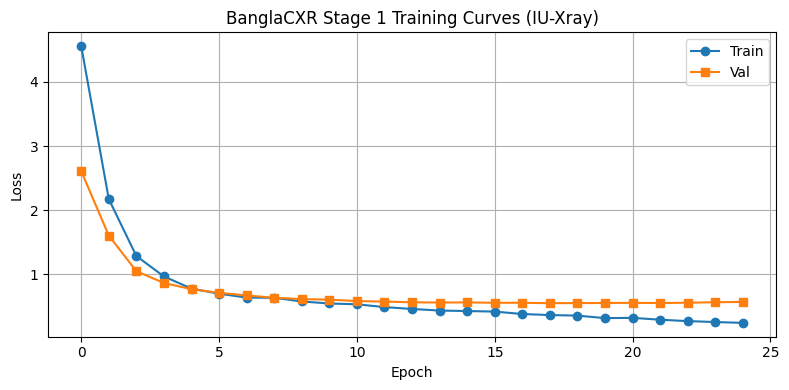

In [35]:
plt.figure(figsize=(8,4))
plt.plot(history['train_loss'], 'o-', label='Train')
plt.plot(history['val_loss'], 's-', label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('BanglaCXR Stage 1 Training Curves (IU-Xray)'); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'curves.png'), dpi=120)
plt.show()

## Cell 18: Evaluation (BLEU & ROUGE)

In [ ]:
# import types, torch, gc
# import numpy as np
# import re
# from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
# from rouge_score import rouge_scorer

# # ── Load Checkpoint ────────────────────────────────────────────
# print('Loading checkpoint...')
# state = torch.load(os.path.join(MODEL_DIR, 'best_model_v2.pt'), map_location='cpu', weights_only=False)
# missing, unexpected = model.load_state_dict(state, strict=False)
# print(f"Loaded. Missing keys (non-bnb): {len([k for k in missing if 'quant' not in k])}")
# print(f"Projector queries sum: {model.projector.queries.sum().item():.4f}")

# del state; torch.cuda.empty_cache(); gc.collect()
# model.eval()
# print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')


# # ── Generation Function ────────────────────────────────────────
# def generate_report_fixed(self, pixel_values, max_new_tokens=200):
#     self.eval()
#     with torch.no_grad():
#         vis_feats  = self.vision_encoder(pixel_values).last_hidden_state.float()
#         proj_feats = self.projector(vis_feats)

#         prompt = (
#             '<|user|>\n<|image_1|>\n'
#             'You are a radiologist. Generate a structured report.\n'
#             'Findings:\nImpression:\n<|end|>\n<|assistant|>\n'
#         )
#         prompt_ids    = self.tokenizer(
#             prompt, return_tensors='pt', add_special_tokens=False
#         ).input_ids.to(DEVICE)
#         prompt_embeds = self.llm.get_input_embeddings()(prompt_ids)
#         context_embeds = torch.cat([proj_feats, prompt_embeds], dim=1)
#         generated_ids = []

#         for step in range(max_new_tokens):
#             if len(generated_ids) == 0:
#                 cur_embeds = context_embeds
#             else:
#                 gen_tensor = torch.tensor([generated_ids], device=DEVICE)
#                 gen_embeds = self.llm.get_input_embeddings()(gen_tensor)
#                 cur_embeds = torch.cat([context_embeds, gen_embeds], dim=1)

#             cur_mask = torch.ones(1, cur_embeds.shape[1], dtype=torch.long, device=DEVICE)
#             out = self.llm(
#                 inputs_embeds=cur_embeds,
#                 attention_mask=cur_mask,
#                 use_cache=False,
#                 return_dict=True
#             )

#             logits = out.logits[:, -1, :].float()
#             if step == 0:
#                 logits[:, self.tokenizer.eos_token_id] = -float('inf')
#             else:
#                 for prev_id in set(generated_ids):
#                     logits[0, prev_id] /= 1.3

#             next_id = logits.argmax(dim=-1).item()
#             if next_id == self.tokenizer.eos_token_id:
#                 break
#             generated_ids.append(next_id)

#         return self.tokenizer.decode(generated_ids, skip_special_tokens=True)


# model.generate_report = types.MethodType(generate_report_fixed, model)


# # ── Quick Test on 1 Sample ─────────────────────────────────────
# print('\n=== TEST SAMPLE ===')
# test_batch = next(iter(test_loader))
# pv  = test_batch['pixel_values'].to(DEVICE, dtype=torch.float16)
# gen = model.generate_report(pv)
# ref = test_df.iloc[0]['report']
# print(f'GEN: {gen[:300]}')
# print(f'REF: {ref[:300]}')


# # ── Full Evaluation ────────────────────────────────────────────
# print('\nRunning full evaluation on test set...')
# generated  = []
# references = []

# model.eval()
# for i, batch in enumerate(test_loader):
#     pv  = batch['pixel_values'].to(DEVICE, dtype=torch.float16)
#     gen = model.generate_report(pv)
#     ref = test_df.iloc[i]['report']
#     generated.append(gen)
#     references.append(ref)
#     if (i + 1) % 50 == 0:
#         print(f'  [{i+1}/{len(test_loader)}] gen: {gen[:80]}...')

# print(f'\nGenerated {len(generated)} reports.')


# # ── BLEU ───────────────────────────────────────────────────────
# smoother = SmoothingFunction().method1
# refs_tok = [[r.split()] for r in references]
# hyps_tok = [g.split()   for g in generated]

# bleu1 = corpus_bleu(refs_tok, hyps_tok, weights=(1,0,0,0),             smoothing_function=smoother)
# bleu2 = corpus_bleu(refs_tok, hyps_tok, weights=(0.5,0.5,0,0),         smoothing_function=smoother)
# bleu4 = corpus_bleu(refs_tok, hyps_tok, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother)


# # ── ROUGE ──────────────────────────────────────────────────────
# scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
# r1_list, r2_list, rL_list = [], [], []

# for gen, ref in zip(generated, references):
#     scores = scorer.score(ref, gen)
#     r1_list.append(scores['rouge1'].fmeasure)
#     r2_list.append(scores['rouge2'].fmeasure)
#     rL_list.append(scores['rougeL'].fmeasure)


# # ── Abnormality Detection Rate ─────────────────────────────────
# ABNORMAL_PATTERNS = [
#     r'(?<!no\s)(?<!without\s)(?<!negative\s)(?<!no evidence of\s)'
#     r'(?<!no focal\s)(?<!clear without\s)'
#     r'\b(consolidation|effusion|pneumothorax|cardiomegaly|'
#     r'atelectasis|infiltrate|opacity|edema|mass|nodule|'
#     r'fracture|enlarged heart|thickening|scarring|hyperexpand|'
#     r'degenerative|scoliosis|kyphosis|granuloma|calcif)\b'
# ]
# def is_truly_abnormal(report):
#     for pattern in ABNORMAL_PATTERNS:
#         if re.search(pattern, report.lower()):
#             return True
#     return False

# true_abn  = [is_truly_abnormal(r) for r in references]
# pred_abn  = [is_truly_abnormal(g) for g in generated]

# tp = sum(t and p for t, p in zip(true_abn, pred_abn))  # abnormal correctly detected
# tn = sum(not t and not p for t, p in zip(true_abn, pred_abn))  # normal correctly identified
# fp = sum(not t and p for t, p in zip(true_abn, pred_abn))  # false alarm
# fn = sum(t and not p for t, p in zip(true_abn, pred_abn))  # missed abnormal

# total_abn  = sum(true_abn)
# detection_rate = tp / total_abn if total_abn > 0 else 0
# precision      = tp / (tp + fp) if (tp + fp) > 0 else 0
# recall         = tp / (tp + fn) if (tp + fn) > 0 else 0
# f1             = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0


# # ── Summary ────────────────────────────────────────────────────
# print('\n' + '='*55)
# print('      EVALUATION SUMMARY — Stage 1 (English)')
# print('='*55)
# print(f'  Test samples     : {len(generated)}')
# print(f'  BLEU-1           : {bleu1:.4f}')
# print(f'  BLEU-2           : {bleu2:.4f}')
# print(f'  BLEU-4           : {bleu4:.4f}')
# print(f'  ROUGE-1          : {np.mean(r1_list):.4f}')
# print(f'  ROUGE-2          : {np.mean(r2_list):.4f}')
# print(f'  ROUGE-L          : {np.mean(rL_list):.4f}')
# print(f'─────────────────────────────────────────────────────')
# print(f'  Abnormal in test : {total_abn} / {len(generated)}')
# print(f'  Detected (TP)    : {tp}  |  Missed (FN): {fn}')
# print(f'  False alarm (FP) : {fp}  |  True neg:    {tn}')
# print(f'  Detection rate   : {detection_rate:.1%}')
# print(f'  Precision        : {precision:.4f}')
# print(f'  Recall           : {recall:.4f}')
# print(f'  F1               : {f1:.4f}')
# print('='*55)

In [17]:
import types, torch, gc, json, os
import numpy as np
import re
from PIL import Image
from torchvision import transforms
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# ── 1. Load & Remap Checkpoint ────────────────────────────────
print('Loading checkpoint...')
state = torch.load(os.path.join(MODEL_DIR, 'best_model_v2.pt'),
                   map_location='cpu', weights_only=False)

# Fix double-wrapped LoRA key prefix
new_state = {}
for k, v in state.items():
    if 'llm.base_model.model.base_model.model.' in k:
        new_k = k.replace(
            'llm.base_model.model.base_model.model.',
            'llm.base_model.model.'
        )
    else:
        new_k = k
    new_state[new_k] = v

missing, unexpected = model.load_state_dict(new_state, strict=False)
non_bnb_missing = [k for k in missing
                   if 'quant' not in k and 'absmax' not in k
                   and 'quant_map' not in k and 'nested' not in k
                   and 'quant_state' not in k]
print(f'Missing keys (non-bnb): {len(non_bnb_missing)}')
if non_bnb_missing:
    print('⚠ Still missing:')
    for k in non_bnb_missing[:5]: print(f'  {k}')
else:
    print('✓ All weights loaded correctly!')

print(f'Projector queries sum: {model.projector.queries.sum().item():.4f}')
del state, new_state; torch.cuda.empty_cache(); gc.collect()
model.eval()
model.llm.config.use_cache = False
print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')


# ── 2. Generation Function ─────────────────────────────────────
def generate_report_fixed(self, pixel_values, max_new_tokens=200):
    self.eval()
    with torch.no_grad():
        vis_feats      = self.vision_encoder(pixel_values).last_hidden_state.float()
        proj_feats     = self.projector(vis_feats)
        prompt = (
            '<|user|>\n<|image_1|>\n'
            'You are a radiologist. Generate a structured report.\n'
            'Findings:\nImpression:\n<|end|>\n<|assistant|>\n'
        )
        prompt_ids     = self.tokenizer(
            prompt, return_tensors='pt', add_special_tokens=False
        ).input_ids.to(DEVICE)
        prompt_embeds  = self.llm.get_input_embeddings()(prompt_ids)
        context_embeds = torch.cat([proj_feats, prompt_embeds], dim=1)
        generated_ids  = []

        for step in range(max_new_tokens):
            cur_embeds = context_embeds if len(generated_ids) == 0 else torch.cat([
                context_embeds,
                self.llm.get_input_embeddings()(
                    torch.tensor([generated_ids], device=DEVICE)
                )
            ], dim=1)
            out = self.llm(
                inputs_embeds=cur_embeds,
                attention_mask=torch.ones(1, cur_embeds.shape[1],
                                          dtype=torch.long, device=DEVICE),
                use_cache=False, return_dict=True
            )
            logits = out.logits[:, -1, :].float()
            if step == 0:
                logits[:, self.tokenizer.eos_token_id] = -float('inf')
            else:
                for prev_id in set(generated_ids):
                    logits[0, prev_id] /= 1.3
            next_id = logits.argmax(dim=-1).item()
            if next_id == self.tokenizer.eos_token_id:
                break
            generated_ids.append(next_id)

        return self.tokenizer.decode(generated_ids, skip_special_tokens=True)

model.generate_report = types.MethodType(generate_report_fixed, model)


# ── 3. Sanity Check ────────────────────────────────────────────
print('\n=== SANITY CHECK (3 samples) ===')
tf = transforms.Compose([
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
for i in range(3):
    row = test_df.iloc[i]
    img = Image.open(os.path.join(IMAGES_DIR, row['filename'])).convert('RGB')
    pv  = tf(img).unsqueeze(0).to(DEVICE, dtype=torch.float16)
    gen = model.generate_report(pv)
    print(f'\n--- Sample {i+1} ---')
    print(f'GEN: {gen[:150]}')
    print(f'REF: {row["report"][:150]}')

# Stop here if sanity check looks like gibberish
print('\n⚠ Check sanity outputs above before continuing.')
print('If outputs are coherent English → proceed. If gibberish → stop.')


# ── 4. Full Generation + JSON Save ────────────────────────────
print(f'\nGenerating {len(test_df)} reports...')
generated  = []
references = []
stage2_data = []

model.eval()
for i, (_, row) in enumerate(test_df.iterrows()):
    img = Image.open(os.path.join(IMAGES_DIR, row['filename'])).convert('RGB')
    pv  = tf(img).unsqueeze(0).to(DEVICE, dtype=torch.float16)
    gen = model.generate_report(pv)
    ref = row['report']

    generated.append(gen)
    references.append(ref)
    stage2_data.append({
        'id':               i,
        'filename':         row['filename'],
        'english_report':   gen,
        'reference_report': ref
    })

    if (i + 1) % 50 == 0:
        print(f'  [{i+1}/{len(test_df)}] {gen[:80]}...')

# Save JSON for Stage 2
json_path = os.path.join(WORKING_DIR, 'stage2_english_reports.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(stage2_data, f, ensure_ascii=False, indent=2)
print(f'\n✓ JSON saved → {json_path}')
print(f'  Sample: {json.dumps(stage2_data[0], indent=2, ensure_ascii=False)[:300]}')


# ── 5. BLEU ────────────────────────────────────────────────────
smoother = SmoothingFunction().method1
refs_tok  = [[r.split()] for r in references]
hyps_tok  = [g.split()   for g in generated]

bleu1 = corpus_bleu(refs_tok, hyps_tok, weights=(1,0,0,0),             smoothing_function=smoother)
bleu2 = corpus_bleu(refs_tok, hyps_tok, weights=(0.5,0.5,0,0),         smoothing_function=smoother)
bleu4 = corpus_bleu(refs_tok, hyps_tok, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother)


# ── 6. ROUGE ───────────────────────────────────────────────────
scorer    = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
r1_list, r2_list, rL_list = [], [], []
for gen, ref in zip(generated, references):
    scores = scorer.score(ref, gen)
    r1_list.append(scores['rouge1'].fmeasure)
    r2_list.append(scores['rouge2'].fmeasure)
    rL_list.append(scores['rougeL'].fmeasure)


# ── 7. Abnormality Detection ───────────────────────────────────
ABNORMAL_PATTERNS = [
    r'(?<!no\s)(?<!without\s)(?<!negative\s)(?<!no evidence of\s)'
    r'(?<!no focal\s)(?<!clear without\s)'
    r'\b(consolidation|effusion|pneumothorax|cardiomegaly|'
    r'atelectasis|infiltrate|opacity|edema|mass|nodule|'
    r'fracture|enlarged heart|thickening|scarring|hyperexpand|'
    r'degenerative|scoliosis|kyphosis|granuloma|calcif)\b'
]
def is_truly_abnormal(report):
    for pattern in ABNORMAL_PATTERNS:
        if re.search(pattern, report.lower()):
            return True
    return False

true_abn = [is_truly_abnormal(r) for r in references]
pred_abn = [is_truly_abnormal(g) for g in generated]

tp = sum(t and p for t, p in zip(true_abn, pred_abn))
tn = sum(not t and not p for t, p in zip(true_abn, pred_abn))
fp = sum(not t and p for t, p in zip(true_abn, pred_abn))
fn = sum(t and not p for t, p in zip(true_abn, pred_abn))

total_abn      = sum(true_abn)
detection_rate = tp / total_abn if total_abn > 0 else 0
precision      = tp / (tp + fp) if (tp + fp) > 0 else 0
recall         = tp / (tp + fn) if (tp + fn) > 0 else 0
f1             = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0


# ── 8. Summary ─────────────────────────────────────────────────
print('\n' + '='*55)
print('      EVALUATION SUMMARY — Stage 1 (English)')
print('='*55)
print(f'  Test samples     : {len(generated)}')
print(f'  BLEU-1           : {bleu1:.4f}')
print(f'  BLEU-2           : {bleu2:.4f}')
print(f'  BLEU-4           : {bleu4:.4f}')
print(f'  ROUGE-1          : {np.mean(r1_list):.4f}')
print(f'  ROUGE-2          : {np.mean(r2_list):.4f}')
print(f'  ROUGE-L          : {np.mean(rL_list):.4f}')
print(f'─────────────────────────────────────────────────────')
print(f'  Abnormal in test : {total_abn} / {len(generated)}')
print(f'  Detected (TP)    : {tp}  |  Missed (FN): {fn}')
print(f'  False alarm (FP) : {fp}  |  True neg:    {tn}')
print(f'  Detection rate   : {detection_rate:.1%}')
print(f'  Precision        : {precision:.4f}')
print(f'  Recall           : {recall:.4f}')
print(f'  F1               : {f1:.4f}')
print('='*55)
print(f'\n✓ Stage 2 JSON ready: {json_path}')

Loading checkpoint...
Missing keys (non-bnb): 0
✓ All weights loaded correctly!
Projector queries sum: -270.2559
VRAM: 3.15 GB

=== SANITY CHECK (3 samples) ===

--- Sample 1 ---
GEN: Findings: The lungs are clear. There is no focal airspace consolidation, pleural effusion or pneumothorax. Heart size and mediastinal contour within n
REF: Findings: The XXXX examination consists of frontal and lateral radiographs of the chest. There are diminished lung volumes. The cardiomediastinal cont

--- Sample 2 ---
GEN: Findings: The lungs are clear. There is no pleural effusion or pneumothorax. Heart and mediastinum of normal size and contour. Degenerative changes in
REF: Findings: Cardiac and mediastinal contours are within normal limits. The lungs are clear. Bony structures are intact.
Impression: No acute findings.

--- Sample 3 ---
GEN: Findings: The heart size and pulmonary vascularity appear within normal limits. No focal airspace disease, pleural effusion or pneumothorax is seen.
I
REF: Fi

In [42]:
## Cell 19: Evaluation (METEOR)

In [38]:
import nltk
from nltk.translate.meteor_score import meteor_score
nltk.download('wordnet', quiet=True)
nltk.download('punkt',   quiet=True)

meteor = np.mean([
    meteor_score([r.split()], g.split())
    for r, g in zip(references, generated)
])
print(f'METEOR : {meteor:.4f}')

METEOR : 0.2820


## Cell 20: Evaluation (chrF++)

In [40]:
import sacrebleu

chrf = np.mean([
    sacrebleu.corpus_chrf([g], [[r]]).score
    for g, r in zip(generated, references)
])
print(f'chrF++: {chrf:.4f}')

chrF++: 41.3185


## Cell 21: Evaluation (CheXbert-F1)

In [48]:
from huggingface_hub import login
login() 

In [50]:
import re
from sklearn.metrics import f1_score, precision_score, recall_score

CLINICAL_LABELS = {
    'Cardiomegaly':      [r'cardiomegaly', r'enlarged heart', r'cardiac enlargement'],
    'Pleural Effusion':  [r'pleural effusion'],
    'Pneumothorax':      [r'pneumothorax'],
    'Consolidation':     [r'(?<!no\s)(?<!without\s)(?<!no focal\s)consolidation'],
    'Atelectasis':       [r'(?<!no\s)atelectasis'],
    'Edema':             [r'(?<!no\s)(?<!without\s)edema'],
    'Lung Opacity':      [r'(?<!no\s)opacity', r'(?<!no\s)opacit'],
    'Nodule/Mass':       [r'(?<!no\s)nodule', r'(?<!no\s)mass', r'(?<!no\s)lesion'],
    'Fracture':          [r'(?<!no\s)fracture'],
    'Hyperinflation':    [r'hyperexpan', r'hyperinflat', r'increased lung volume'],
    'Degenerative':      [r'degenerative', r'scoliosis', r'kyphosis'],
    'No Finding':        [r'no acute', r'unremarkable', r'no evidence', r'within normal limits'],
}

def extract_labels(text):
    text = text.lower()
    return [int(any(re.search(p, text) for p in patterns))
            for patterns in CLINICAL_LABELS.values()]

print('Extracting clinical labels...')
gen_labels = np.array([extract_labels(g) for g in generated])
ref_labels = np.array([extract_labels(r) for r in references])
label_names = list(CLINICAL_LABELS.keys())

print('\nPer-label Clinical F1:')
label_f1s = []
for i, label in enumerate(label_names):
    f1 = f1_score(ref_labels[:, i], gen_labels[:, i], zero_division=0)
    pr = precision_score(ref_labels[:, i], gen_labels[:, i], zero_division=0)
    rc = recall_score(ref_labels[:, i], gen_labels[:, i], zero_division=0)
    label_f1s.append(f1)
    print(f'  {label:<20}: P={pr:.3f}  R={rc:.3f}  F1={f1:.4f}')

macro_f1    = f1_score(ref_labels, gen_labels, average='macro',    zero_division=0)
micro_f1    = f1_score(ref_labels, gen_labels, average='micro',    zero_division=0)
weighted_f1 = f1_score(ref_labels, gen_labels, average='weighted', zero_division=0)

print(f'\nClinical Macro-F1   : {macro_f1:.4f}')
print(f'Clinical Micro-F1   : {micro_f1:.4f}')
print(f'Clinical Weighted-F1: {weighted_f1:.4f}')

Extracting clinical labels...

Per-label Clinical F1:
  Cardiomegaly        : P=0.444  R=0.245  F1=0.3158
  Pleural Effusion    : P=0.610  R=0.867  F1=0.7164
  Pneumothorax        : P=0.646  R=0.904  F1=0.7532
  Consolidation       : P=0.208  R=0.474  F1=0.2895
  Atelectasis         : P=0.200  R=0.333  F1=0.2500
  Edema               : P=0.158  R=0.105  F1=0.1263
  Lung Opacity        : P=0.362  R=0.223  F1=0.2762
  Nodule/Mass         : P=0.105  R=0.080  F1=0.0909
  Fracture            : P=0.000  R=0.000  F1=0.0000
  Hyperinflation      : P=0.333  R=0.176  F1=0.2308
  Degenerative        : P=0.190  R=0.111  F1=0.1404
  No Finding          : P=0.765  R=0.830  F1=0.7962

Clinical Macro-F1   : 0.3321
Clinical Micro-F1   : 0.5897
Clinical Weighted-F1: 0.5746


In [ ]:
## Cell 22: Evaluation (BERTScore)